In [1]:
import torch    
import json 
from ptlpinns.models import model, transfer
from ptlpinns.perturbation import LPM, standard, LKV
from ptlpinns.odes import forcing, numerical, equations
import numpy as np
import math

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load model

In [2]:
name = "undamped_k12"

undamped_path = f"/home/jovyan/PTL-PINNs/ptlpinns/models/train/{name}"
undamped_name = f"model_{name}.pth"
undamped_model, training_log = model.load_model(undamped_path, undamped_name)

12 True True True 1.0 16 [256, 256, 512]


### Problem definition

In [3]:
N = 512
t_span = (0, 15)
t_eval = np.linspace(t_span[0], t_span[1], N)

### Compute latent representations

In [4]:
H_dict = transfer.compute_H_dict(undamped_model, N=N, bias=True, t_span=t_span)

### Transfer parameters

In [5]:
w_list_transfer = [1]
zeta_list = [0.0]
forcing_list = [forcing.zeroes_2D(numpy=True)]
ic_list = [[1, 0]]
epsilon_list = [0.6]
p_list = [6]
q = [(3, 1)]

In [6]:
ode = equations.ode_oscillator_1D(w_0=w_list_transfer[0], zeta=zeta_list[0], forcing_1D=lambda t: np.zeros_like(t), q=q, epsilon=epsilon_list[0])
numerical_undamped_duffing = numerical.solve_ode_equation(ode, (t_eval[0], t_eval[-1]), t_eval, ic_list[0])

## Standard Perturbation

In [7]:
NN_TL_solution_standard, perturbation_solution_standard, _ = transfer.compute_perturbation_solution(w_list_transfer, zeta_list, epsilon_list, p_list, ic_list, forcing_list, H_dict, t_eval, training_log, all_p=True, comp_time=False, solver="standard", power=q)
NN_TL_solution_standard = NN_TL_solution_standard.squeeze()

In [8]:
NN_TL_solution_standard, perturbation_solution_standard, _ = transfer.compute_perturbation_solution(w_list_transfer, zeta_list, epsilon_list, p_list, ic_list, forcing_list, H_dict, t_eval, training_log, all_p=True, comp_time=False, solver="standard", power=q)
NN_TL_solution_standard = NN_TL_solution_standard.squeeze()

PINN_x_solution_standard = [perturbation_solution_standard[i][:, 0] for i in range(len(perturbation_solution_standard))]
PINN_x_solution_series_standard = standard.calculate_general_series(PINN_x_solution_standard, epsilon=epsilon_list[0])

In [9]:
PINN_x_solution_standard = [perturbation_solution_standard[i][:, 0] for i in range(len(perturbation_solution_standard))]
PINN_x_solution_series_standard = standard.calculate_general_series(PINN_x_solution_standard, epsilon=epsilon_list[0])

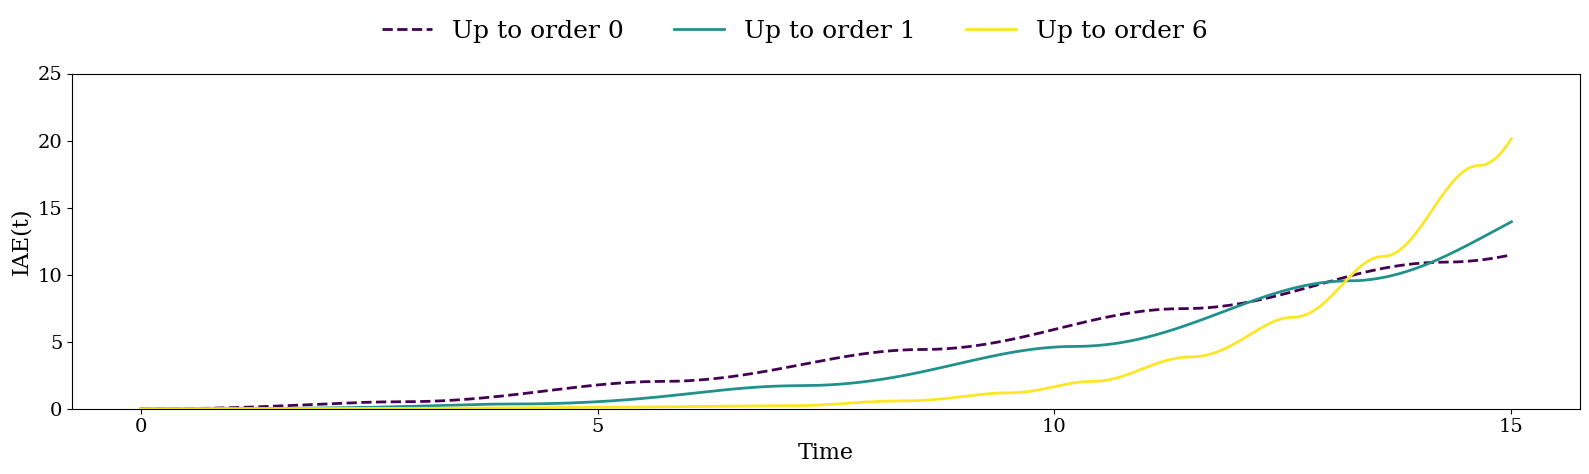

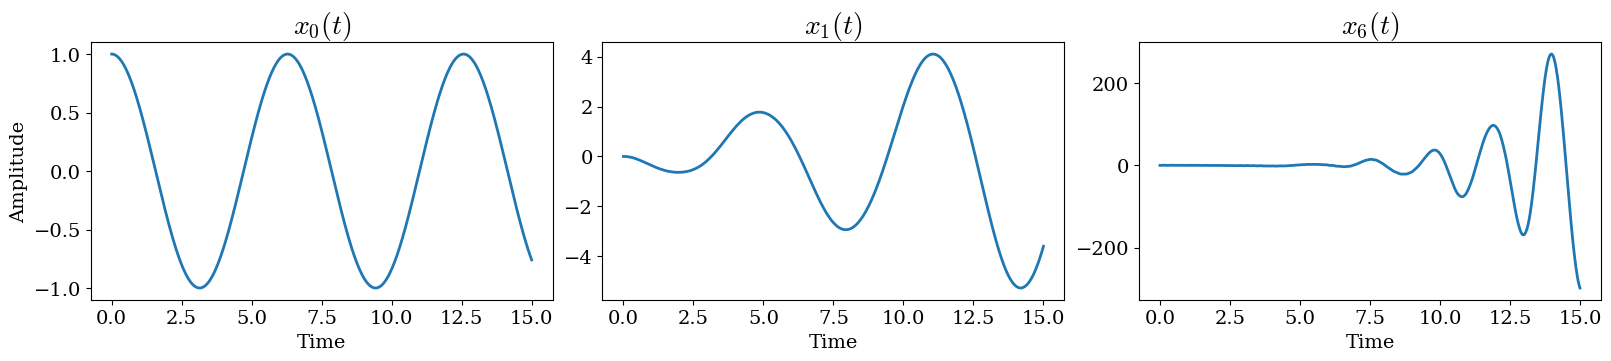

In [10]:
standard.plot_IAE_and_subplots(PINN_x_solution_series_standard, numerical_undamped_duffing, perturbation_solution_standard, t_eval, selected_orders=[0, 1, 6])

## Lindstedt-Poincare method

In [11]:
w_sol = []
NN_TL_solution_LPM, perturbation_solution_LPM, _ = transfer.compute_perturbation_solution(w_list_transfer, zeta_list, epsilon_list, p_list, ic_list, forcing_list, H_dict, t_eval, training_log, all_p=True, comp_time=False, solver="LPM", w_sol = w_sol, power=q)
NN_TL_solution_LPM = NN_TL_solution_LPM.squeeze()

In [12]:
w_final_list = []

for index in range(len(epsilon_list)):
    w_final_list.append(LPM.calculate_w_series(w_sol[0], epsilon_list[index], rwtol=1e-12))

w_final_list

[[1,
  np.float64(1.2249351568951867),
  np.float64(1.1954310758629814),
  np.float64(1.2039570187286073),
  np.float64(1.2007301710704892),
  np.float64(1.20212267247765),
  np.float64(1.2014758688736928)]]

In [13]:
_, w_teor = LPM.estimate_period_frequency(w_0=w_list_transfer[0], zeta=zeta_list[0], ic=ic_list[0], q=q, epsilon=epsilon_list[0])
w_teor

np.float64(1.2018028846153845)

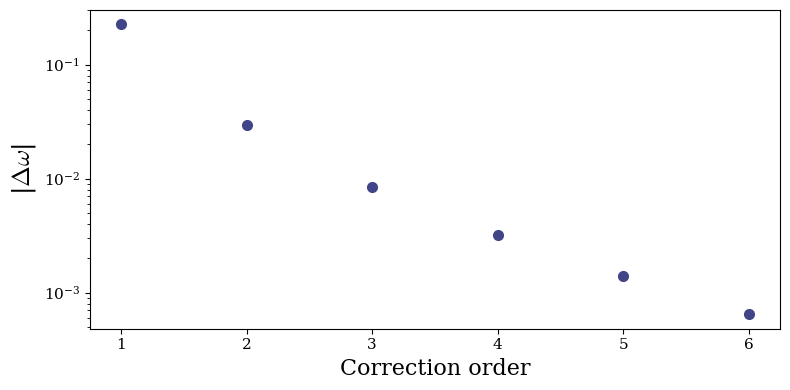

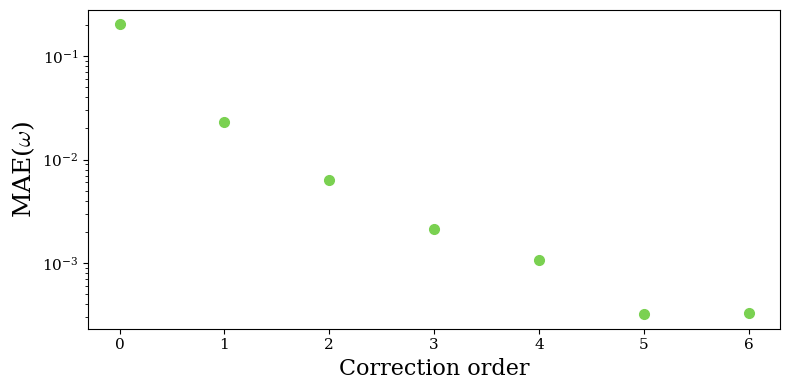

In [14]:
LPM.relative_error(w_final_list[0])
LPM.w_absolute_error(w_final_list[0], w_teor)

In [15]:
w_final = w_final_list[0][-1]
t_eval_lpm, t_eval_standard = LPM.t_eval_lpm(t_eval, w_final)
compare_len = t_eval_standard.shape[0]

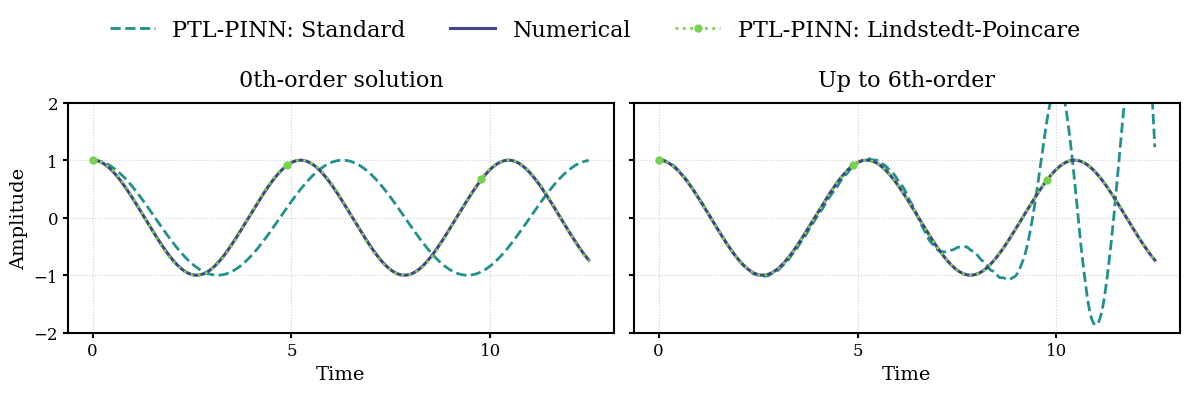

In [16]:
standard.plot_comparison_standard_vs_lpm(t_eval_standard, t_eval_lpm, [i[:compare_len] for i in perturbation_solution_standard], NN_TL_solution_standard[:compare_len], perturbation_solution_LPM, NN_TL_solution_LPM, numerical_undamped_duffing[:, :compare_len], order=p_list[0])

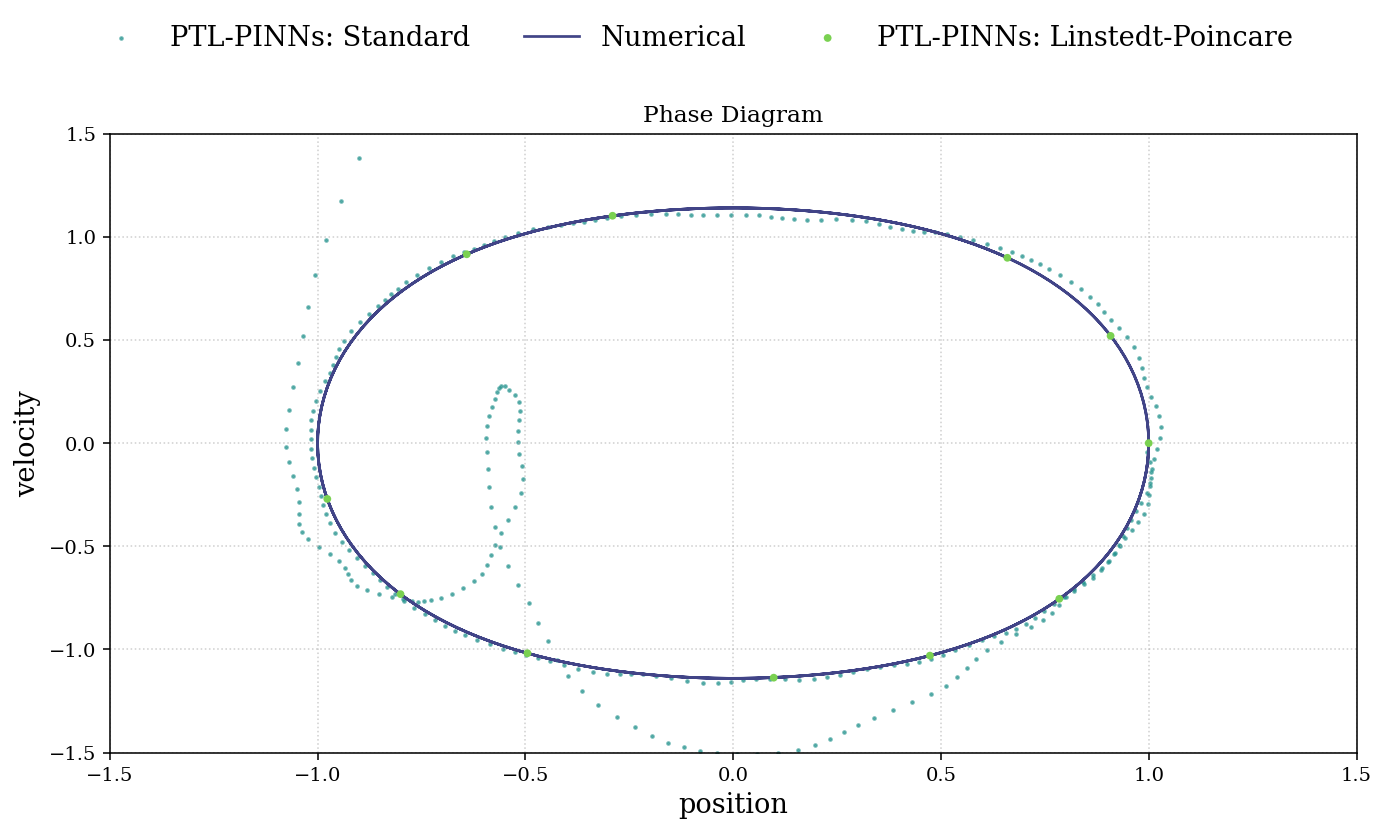

In [17]:
LPM.plot_multiple_phase_diagrams(
    [NN_TL_solution_LPM, numerical_undamped_duffing, NN_TL_solution_standard],
    labels=["PTL-PINNs: Linstedt-Poincare", "Numerical", "PTL-PINNs: Standard"],
    lpm_index=0,
    omega=w_teor,
    lpm_stride=50,
    xlim=(-1.5, 1.5),
    ylim=(-1.5, 1.5))

/tmp/ipykernel_31402/1663168197.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", 3)


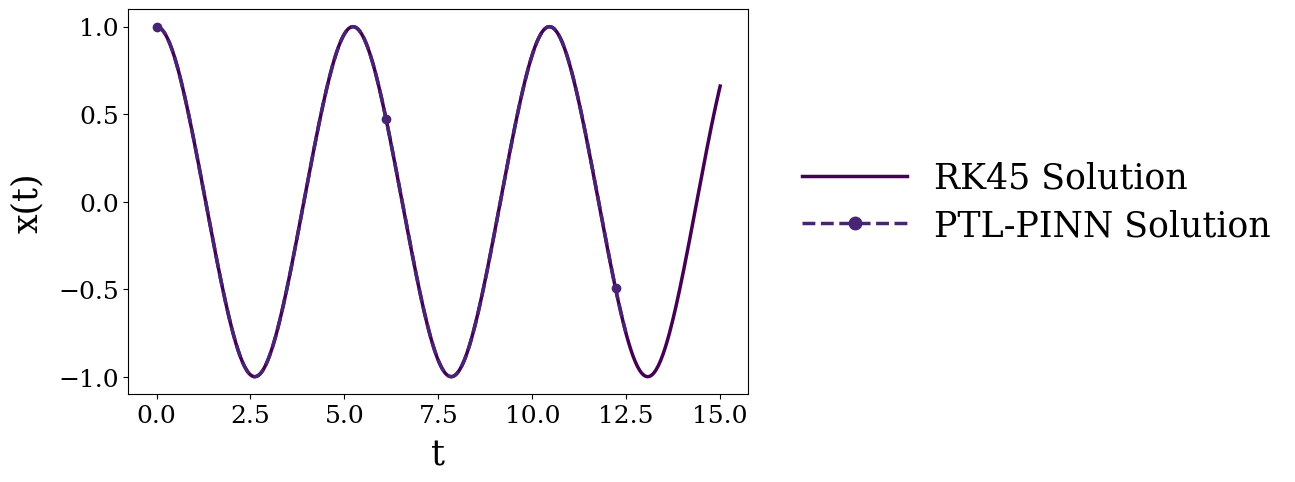

In [18]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
})

def plot_solution(t_eval, t_eval_lpm, y_num, y_nn, i = 0):
    title_fs  = 25
    label_fs  = 25
    tick_fs   = 18
    legend_fs = 25
    cmap = cm.get_cmap("viridis", 3)

    fig, ax = plt.subplots(figsize=(8, 5))

    base_color = cmap(i / 2)
    rk_color   = base_color
    pinn_color = cm.viridis(0.1 + 0.8 * i / 2)


    ax.plot(t_eval, y_num,
            label="RK45 Solution",
            color=rk_color, linewidth=2.5)

    ax.plot(t_eval_lpm, y_nn,
            label="PTL-PINN Solution",
            color=pinn_color, linewidth=2.5,
            linestyle="--", marker="o", markevery=250)

    ax.set_xlabel("t", fontsize=label_fs, labelpad=8)
    ax.set_ylabel("x(t)", fontsize=label_fs, labelpad=10)

    ax.tick_params(axis='both', labelsize=tick_fs)

    # Set y-limits with padding
    y_min = min(np.min(y_num), np.min(y_nn))
    y_max = max(np.max(y_num), np.max(y_nn))
    pad = 0.05 * max(1e-12, (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # (x, y): anchor the legend outside the right border
    fontsize=legend_fs,
    frameon=False,
    handlelength=3.0,
    markerscale=1.5,
    labelspacing=0.4,
    borderaxespad=0.8)
    plt.show()

plot_solution(t_eval[:4000], t_eval_lpm[:4800], numerical_undamped_duffing[0, :4000], NN_TL_solution_LPM[:4800, 0], i = 0)

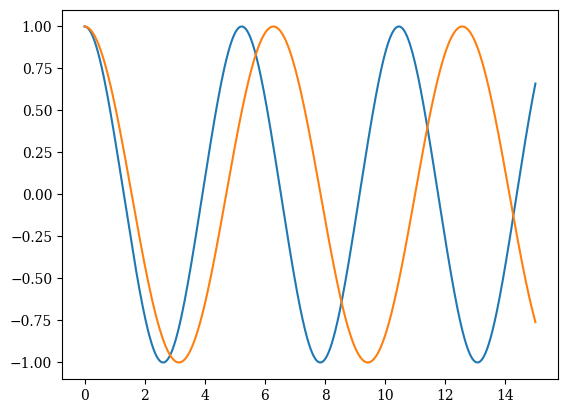

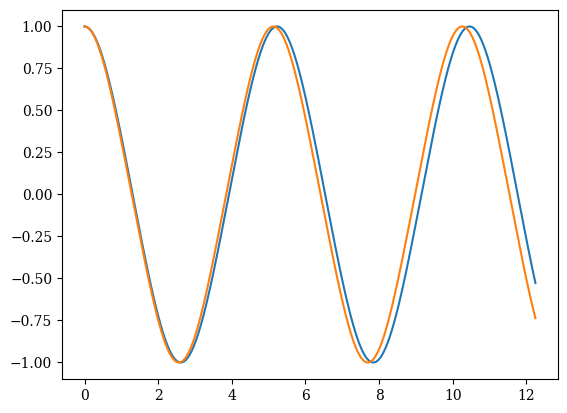

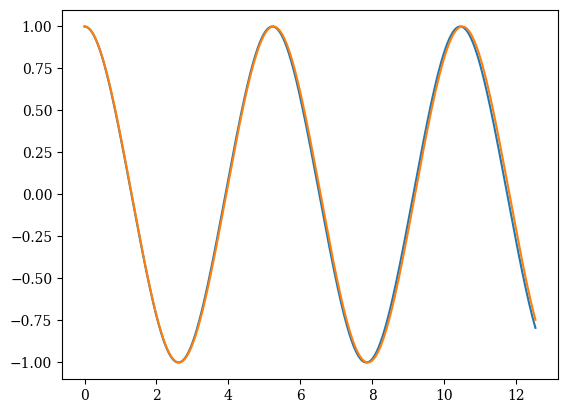

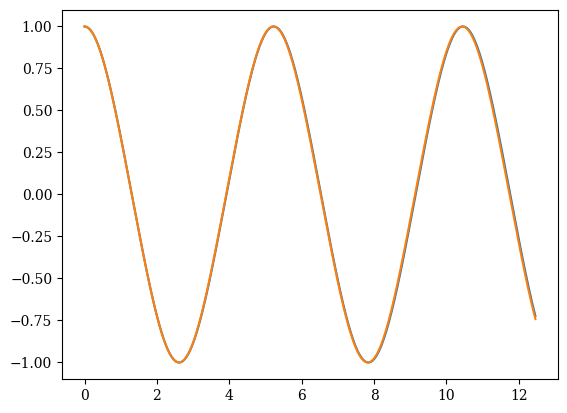

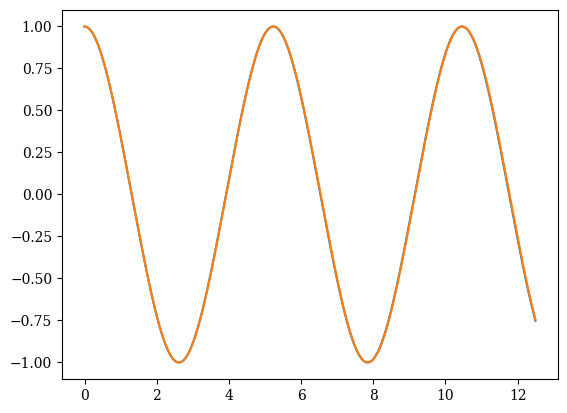

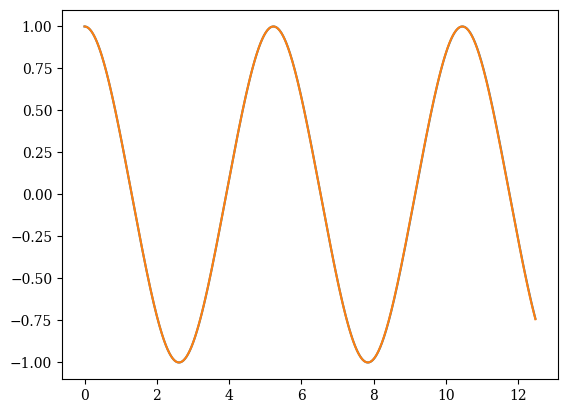

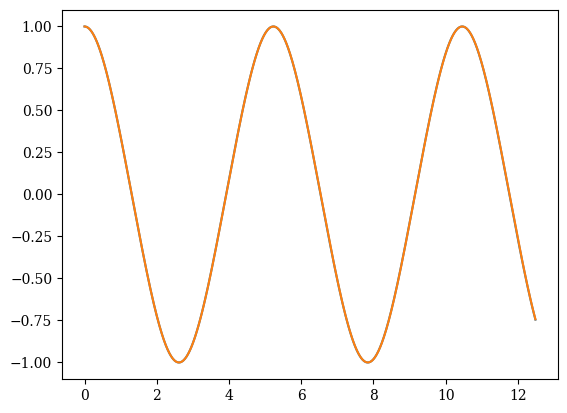

In [19]:
w_final = []
xi_final = []
error = []
epsilon = epsilon_list[0]

for i in range(len(w_sol[0])):

    w_loop = w_final_list[0][i]

    if i == 0:
        xi_loop = perturbation_solution_LPM[0][:, 0]
    else:
        xi_loop  = xi_final[i - 1] + (epsilon ** i) * perturbation_solution_LPM[i][:, 0]

    w_final.append(w_loop)
    xi_final.append(xi_loop)

    t_span_loop = (0, t_span[-1]/w_loop)
    t_eval_loop_ptl = np.linspace(t_span_loop[0], t_span_loop[1], N)
    dt = (t_eval_loop_ptl[1] - t_eval_loop_ptl[0])/100
    #t_eval_loop = np.arange(t_span_loop[0], t_span_loop[1] + dt, dt)
    t_eval_loop = np.linspace(t_span_loop[0], t_span_loop[1], (t_eval_loop_ptl.size - 1)*100 + 1)
    x_loop = numerical.solve_ode_equation(ode, (t_eval_loop[0], t_eval_loop[-1]), t_eval_loop, ic_list[0])[0, :]

    error.append(np.mean(np.abs(xi_loop - x_loop[::100])))

    plt.plot(t_eval_loop, x_loop)
    plt.plot(t_eval_loop_ptl, xi_loop)
    plt.show()

In [20]:
error

[np.float64(0.7648997816662615),
 np.float64(0.0942228243536427),
 np.float64(0.026155496665471557),
 np.float64(0.009362585892838334),
 np.float64(0.004038338288149609),
 np.float64(0.001762522057898674),
 np.float64(0.0009404174055715934)]

In [21]:
error

[np.float64(0.7648997816662615),
 np.float64(0.0942228243536427),
 np.float64(0.026155496665471557),
 np.float64(0.009362585892838334),
 np.float64(0.004038338288149609),
 np.float64(0.001762522057898674),
 np.float64(0.0009404174055715934)]

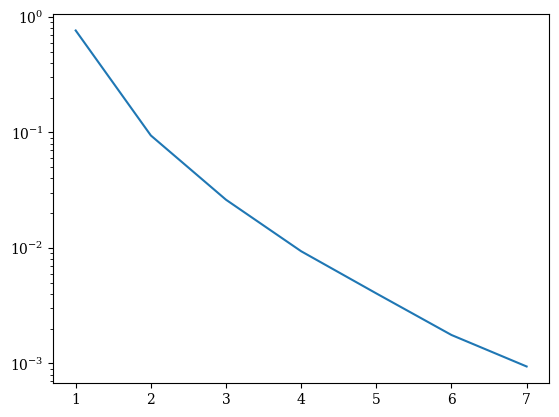

In [22]:
plt.semilogy([1, 2, 3, 4, 5, 6, 7], error) 

## Hyperparameter sweep — MAE vs perturbation order

The undamped Duffing-like oscillator
$\ddot x + x + \varepsilon\, x^3 = 0,\ x(0)=1,\ \dot x(0)=0$
is solved with the Lindstedt-Poincaré method on top of several latent-space
choices, mirroring the Lotka-Volterra study:

- **Pretrained PINN backbones** — `undamped_k12` (12 heads) and `undamped_k1`
  (1 head), both with sine first layer and Fourier features.
- **Random PINN architectures** — untrained networks where we vary
  `use_sine ∈ {True, False}`, Fourier-feature `scale ∈ {1, 5}`,
  `n_frequencies ∈ {16, 64}`, and a tanh / no-Fourier ablation.
- **Random tanh, no Fourier** — width sweep `W ∈ {32, 64, 128, 256, 512}`.
- **Fourier features** — `compute_H_dict_fourier` with QR-orthogonalisation
  (default) and a *raw* variant, each at `n_modes ∈ {16, 64}`.

For each configuration we record the MAE of the cumulative position estimate
$\sum_{k=0}^{p} \varepsilon^k\,\xi_k$ against a high-resolution numerical
reference, for every perturbation order $p = 0,\dots,p_{\max}$.

In [ ]:
from ptlpinns.models.model import Multihead_model_fourier, load_model


def _make_pretrained_dict(model_name):
    path = f"/home/jovyan/PTL-PINNs/ptlpinns/models/train/{model_name}"
    fname = f"model_{model_name}.pth"
    pretrained, tlog = load_model(path, fname)
    return transfer.compute_H_dict(pretrained, N=N, bias=True, t_span=t_span), tlog


def _make_random_dict(use_sine, scale, n_frequencies, tlog_template,
                     use_fourier=True, hidden_layers=None, seed=0):
    """Random PINN with requested architectural hyper-parameters (no training)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    hidden_layers = hidden_layers or tlog_template["hidden_layers"]
    rand_model = Multihead_model_fourier(
        k=tlog_template["k"],
        bias=tlog_template["bias"],
        use_sine=use_sine,
        use_fourier=use_fourier,
        scale=scale,
        n_frequencies=n_frequencies,
        HIDDEN_LAYERS=hidden_layers,
    )
    return transfer.compute_H_dict(rand_model, N=N, bias=True, t_span=t_span), tlog_template


def _make_fourier_dict(n_modes, N_f=N, orthogonalize=True, tlog_template=None):
    Hd = transfer.compute_H_dict_fourier(
        N=N_f, bias=True, t_span=t_span, n_modes=n_modes, orthogonalize=orthogonalize,
    )
    return Hd, tlog_template


p_max = 6   # match the original notebook's p_list = [6]

sweep_configs = [
    # (label, factory)

    # --- Pretrained baselines ---
    # The first entry reuses the *actual* `H_dict` already built from
    # `undamped_model` earlier, not a re-load — so the legend entry is
    # literally the model used in the rest of the notebook.
    ("Pretrained $H$ (undamped_k12, actual model)",
        lambda: (H_dict, training_log)),
    ("Pretrained $H$ (undamped_k1)",
        lambda: _make_pretrained_dict("undamped_k1")),


    ("Random $H$ (tanh, no Fourier, W=32)",
        lambda: _make_random_dict(use_sine=False, scale=1.0, n_frequencies=16,
                                  use_fourier=False, hidden_layers=[32, 32, 64],
                                  tlog_template=training_log)),
    ("Random $H$ (tanh, no Fourier, W=64)",
        lambda: _make_random_dict(use_sine=False, scale=1.0, n_frequencies=16,
                                  use_fourier=False, hidden_layers=[64, 64, 128],
                                  tlog_template=training_log)),
    ("Random $H$ (tanh, no Fourier, W=128)",
        lambda: _make_random_dict(use_sine=False, scale=1.0, n_frequencies=16,
                                  use_fourier=False, hidden_layers=[128, 128, 256],
                                  tlog_template=training_log)),
    ("Random $H$ (tanh, no Fourier, W=256)",
        lambda: _make_random_dict(use_sine=False, scale=1.0, n_frequencies=16,
                                  use_fourier=False, hidden_layers=[256, 256, 512],
                                  tlog_template=training_log)),
    ("Random $H$ (tanh, no Fourier, W=512)",
        lambda: _make_random_dict(use_sine=False, scale=1.0, n_frequencies=16,
                                  use_fourier=False, hidden_layers=[512, 512, 1024],
                                  tlog_template=training_log)),

]
[label for label, _ in sweep_configs]

['Pretrained $H$ (undamped_k12, actual model)',
 'Pretrained $H$ (undamped_k1)',
 'Random $H$ (tanh, no Fourier, W=32)',
 'Random $H$ (tanh, no Fourier, W=64)',
 'Random $H$ (tanh, no Fourier, W=128)',
 'Random $H$ (tanh, no Fourier, W=256)',
 'Random $H$ (tanh, no Fourier, W=512)']

In [ ]:
errors_by_label = {}

for label, factory in sweep_configs:
    H_cfg, tlog = factory()
    n_grid = H_cfg["N"]
    t_eval_cfg = np.linspace(t_span[0], t_span[1], n_grid)

    cond_H = np.linalg.cond(H_cfg["H"])

    err, w_cfg = LPM.compute_error_per_order_lpm(
        H_dict=H_cfg,
        training_log=tlog,
        w_0=w_list_transfer[0],
        zeta=zeta_list[0],
        epsilon=epsilon_list[0],
        p_max=p_max,
        ic=ic_list[0],
        forcing_function=forcing_list[0],
        q=q,
        ode=ode,
        t_eval=t_eval_cfg,
        t_span=t_span,
        N=n_grid,
    )

    # Bake cond(H) and final MAE into the legend label so the plot is
    # self-contained.
    legend_label = (
        f"{label}  [$\\kappa(H)$={cond_H:.1e}, "
        f"MAE@$p$={len(err) - 1}: {err[-1]:.2e}]"
    )
    errors_by_label[legend_label] = err
    print(f"{label:<48s}  MAE @ p={len(err) - 1}: {err[-1]:.3e}  |  cond(H)={cond_H:.2e}")

errors_by_label

Pretrained $H$ (undamped_k12, actual model)       MAE @ p=6: 9.404e-04  |  cond(H)=3.94e+05
1 True True True 1.0 16 [256, 256, 512]


Pretrained $H$ (undamped_k1)                      MAE @ p=6: 4.145e-02  |  cond(H)=1.24e+04


Random $H$ (tanh, no Fourier, W=32)               MAE @ p=6: 1.251e-01  |  cond(H)=2.30e+04


Random $H$ (tanh, no Fourier, W=64)               MAE @ p=6: 7.653e-04  |  cond(H)=5.84e+06


Random $H$ (tanh, no Fourier, W=128)              MAE @ p=6: 9.516e-04  |  cond(H)=2.11e+11


Random $H$ (tanh, no Fourier, W=256)              MAE @ p=6: 6.623e-04  |  cond(H)=1.57e+16


Random $H$ (tanh, no Fourier, W=512)              MAE @ p=6: 8.322e-04  |  cond(H)=2.77e+16


{'Pretrained $H$ (undamped_k12, actual model)  [$\\kappa(H)$=3.9e+05, MAE@$p$=6: 9.40e-04]': [np.float64(0.7648997816662615),
  np.float64(0.0942228243536427),
  np.float64(0.026155496665471557),
  np.float64(0.009362585892838334),
  np.float64(0.004038338288149609),
  np.float64(0.001762522057898674),
  np.float64(0.0009404174055715934)],
 'Pretrained $H$ (undamped_k1)  [$\\kappa(H)$=1.2e+04, MAE@$p$=6: 4.15e-02]': [np.float64(0.7598831023865128),
  np.float64(0.07169680168080902),
  np.float64(0.048388017887712166),
  np.float64(0.017954503801031092),
  np.float64(0.026113035509041954),
  np.float64(0.04073253241194259),
  np.float64(0.041454059974690566)],
 'Random $H$ (tanh, no Fourier, W=32)  [$\\kappa(H)$=2.3e+04, MAE@$p$=6: 1.25e-01]': [np.float64(0.6553301641739409),
  np.float64(0.11876406501843136),
  np.float64(0.1216088351468345),
  np.float64(0.11888299334190647),
  np.float64(0.13702808814840822),
  np.float64(0.12154167510093188),
  np.float64(0.1251286803175124)],
 'Ran

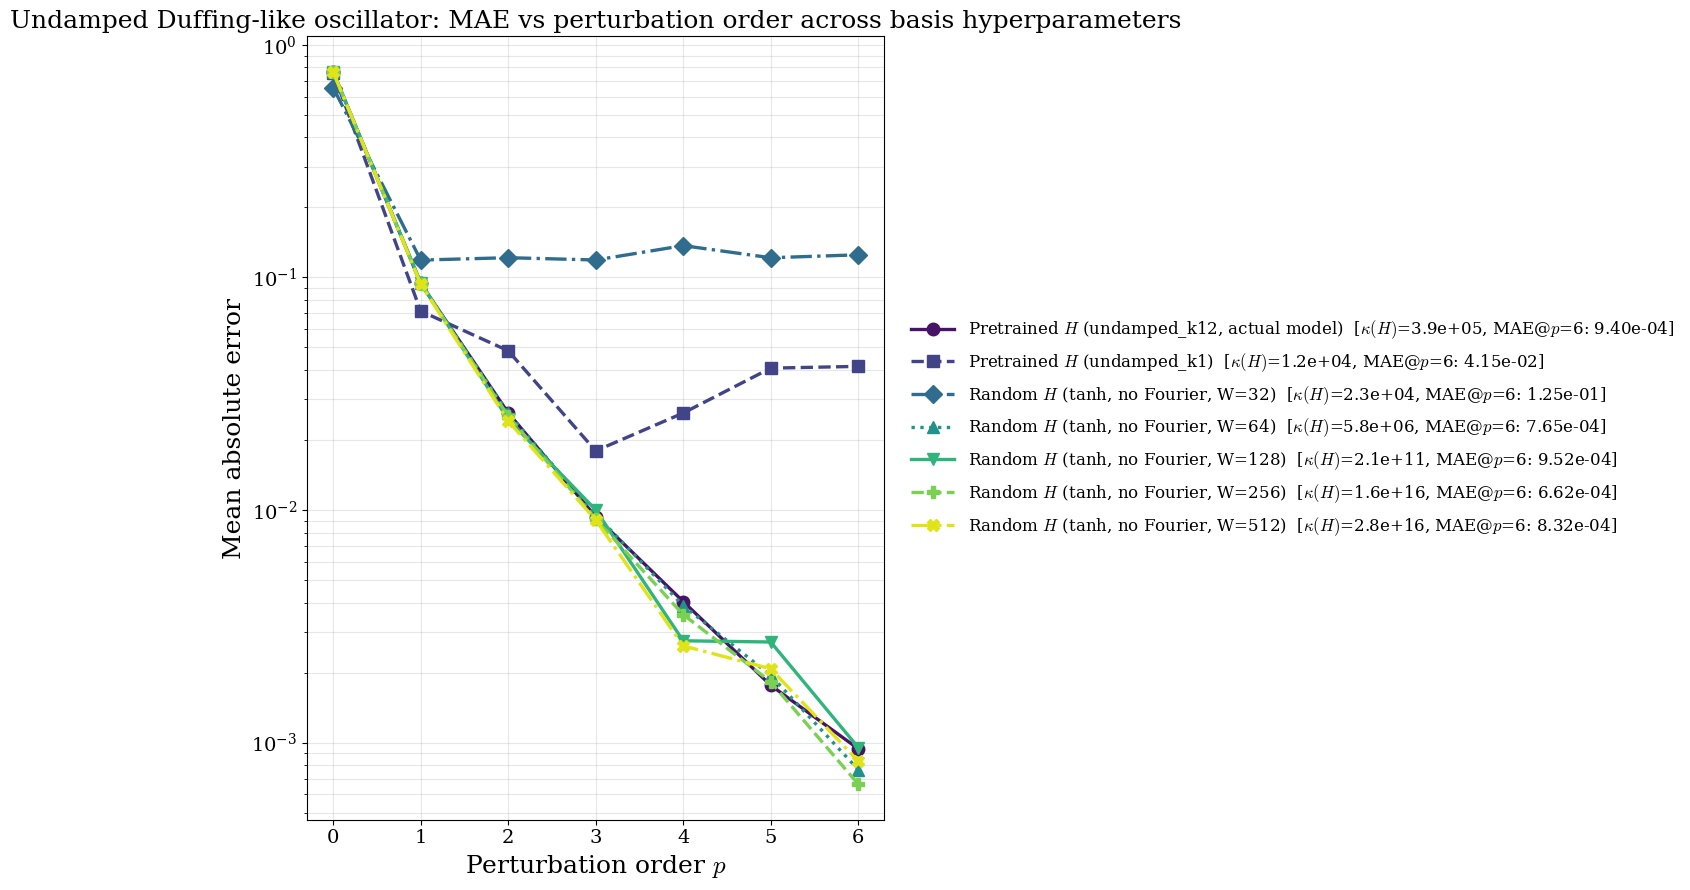

(<Figure size 1500x900 with 1 Axes>,
 <Axes: title={'center': 'Undamped Duffing-like oscillator: MAE vs perturbation order across basis hyperparameters'}, xlabel='Perturbation order $p$', ylabel='Mean absolute error'>)

In [ ]:
LKV.plot_mae_vs_order(
    errors_by_label,
    title=r"Undamped Duffing-like oscillator: MAE vs perturbation order across basis hyperparameters",
)